# Classical Detector — Peak Amplitude Threshold

Each waveform is already z-score normalised (mean=0, std=1 per trace).  
The idea: an earthquake has a burst of energy at P/S arrivals, pushing some samples far from zero.  
We measure `max|x|` — the largest deviation in units of std — and classify as earthquake if it exceeds a threshold.

This is the **classical baseline** we compare the CNN against.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../../..').resolve()))

from src.classifier.classical import plot_feature_distributions, find_threshold, evaluate

DATA = str(Path('../../../data').resolve())

## Stage 1 — Feature distributions

`max|x|` separates the two classes well: earthquakes average ~14σ, noise ~5σ.  
Kurtosis (how 'peaky' the waveform is) also separates them but with more overlap — we stick with `max|x|` for the classifier.

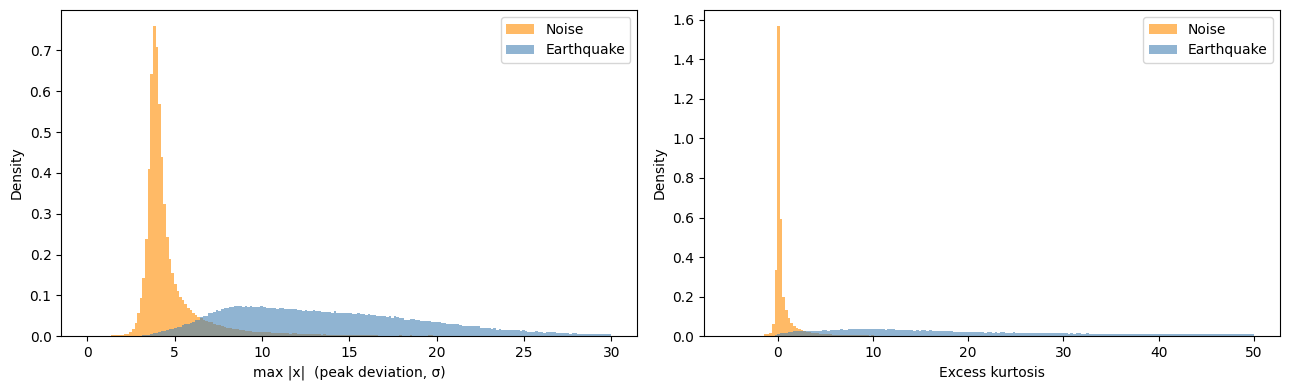

In [2]:
plot_feature_distributions(DATA)

## Stage 2 — Threshold tuning

Sweep 1000 candidate thresholds on the **training set only** and pick the one with the highest F1.  
Using the training set here prevents data leakage into the test evaluation.

Best threshold : 6.527 σ
Train F1       : 0.9000


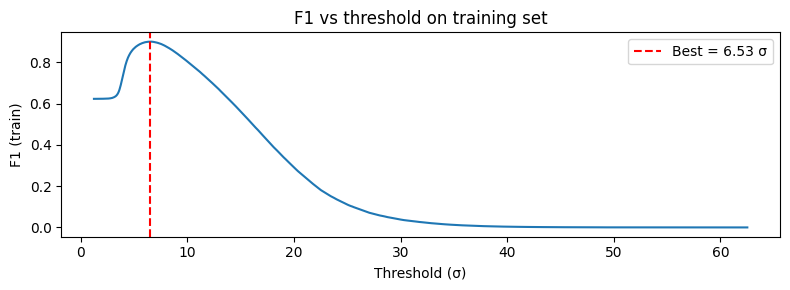

In [3]:
threshold = find_threshold(DATA)

## Stage 3 — Test set evaluation

Apply the threshold found above to the held-out test set.  
Expected: F1 ≈ 0.90, AUC-ROC ≈ 0.96 — well below the CNN (F1 ≈ 0.998).

Test set metrics — classical baseline
              precision    recall  f1-score   support

       Noise     0.9414    0.8809    0.9101     58588
  Earthquake     0.8661    0.9335    0.8985     48333

    accuracy                         0.9047    106921
   macro avg     0.9037    0.9072    0.9043    106921
weighted avg     0.9073    0.9047    0.9049    106921

f1          : 0.9043
accuracy    : 0.9047
precision   : 0.8661
recall      : 0.9335
auc_roc     : 0.9576


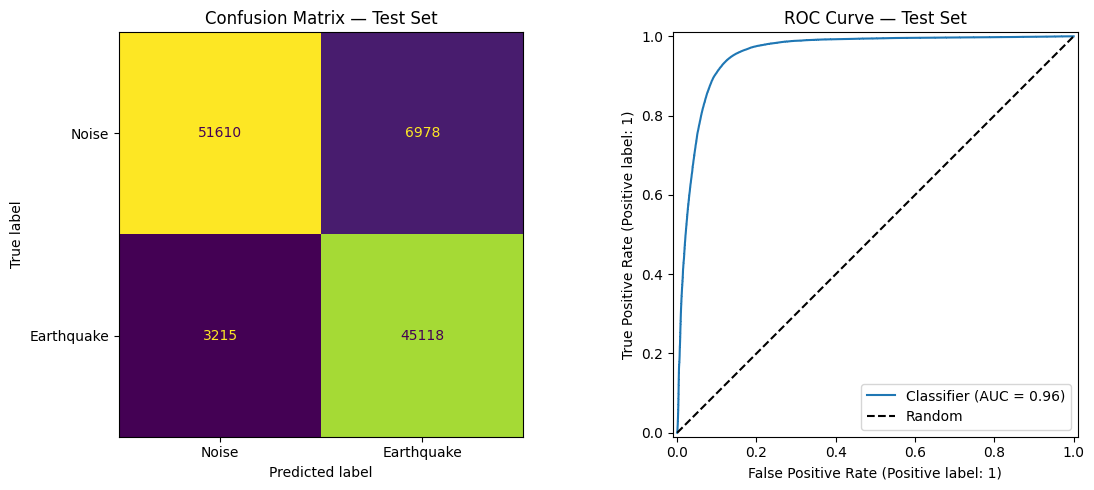

In [4]:
metrics = evaluate(threshold, DATA)